# Chapitre 2 — Leçon 3 : Le Pattern Fit/Predict et l'Évaluation des Modèles

**Durée estimée : 3h**

## Objectifs d'apprentissage

À la fin de cette leçon, vous serez capable de :
- **Utiliser** l'API universelle de scikit-learn : `.fit()`, `.predict()`, `.score()`
- **Distinguer** les paramètres (appris) des hyperparamètres (définis)
- **Analyser** une matrice de confusion pour diagnostiquer les erreurs d'un modèle
- **Calculer** et interpréter les métriques de classification (Precision, Recall, F1, ROC-AUC)
- **Calculer** et interpréter les métriques de régression (MAE, RMSE, R²)
- **Choisir** la bonne métrique selon le contexte business

---

## 🎯 Accroche : Un langage universel

Imaginez que vous devez apprendre à utiliser 50 outils différents — chacun avec sa propre interface, ses propres commandes, sa propre logique. Ce serait épuisant !

Maintenant imaginez que tous ces outils partagent **exactement la même interface** : trois boutons qui font toujours la même chose.

C'est la philosophie de scikit-learn : **TOUS les modèles utilisent le même pattern**.

**Question :** Si vous apprenez à utiliser UN modèle scikit-learn, combien de modèles savez-vous utiliser ?

*(Réponse attendue : Tous ! Car ils partagent tous la même API)*

---

## 3.1 L'API universelle scikit-learn

### Les trois méthodes magiques

Voici le cœur de scikit-learn — trois méthodes que partagent TOUS les modèles :

```
┌─────────────────────────────────────────────────────────────────┐
│                 L'API UNIVERSELLE SCIKIT-LEARN                  │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│   ┌─────────────┐                                               │
│   │   .fit()    │  "Apprends à partir de ces données"          │
│   │             │  Entrée : X_train, y_train                    │
│   │             │  Le modèle ajuste ses paramètres internes     │
│   └─────────────┘                                               │
│          │                                                      │
│          ▼                                                      │
│   ┌─────────────┐                                               │
│   │ .predict()  │  "Fais des prédictions"                       │
│   │             │  Entrée : X_new (nouvelles données)           │
│   │             │  Sortie : y_pred (prédictions)                │
│   └─────────────┘                                               │
│          │                                                      │
│          ▼                                                      │
│   ┌─────────────┐                                               │
│   │  .score()   │  "Évalue ta performance"                      │
│   │             │  Entrée : X_test, y_test                      │
│   │             │  Sortie : score de performance                │
│   └─────────────┘                                               │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
```

### Voyons cela en action

Commençons par préparer un dataset simple pour nos expériences.

In [1]:
# Importations nécessaires
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris, make_regression

# Créons un dataset de régression simple
X, y = make_regression(n_samples=200, n_features=3, noise=10, random_state=42)
# make_regression génère des données de régression linéaire avec du bruit
# n_samples: nombre d'exemples
# n_features: nombre de caractéristiques
# noise: niveau de bruit ajouté aux données
# x est une matrice de caractéristiques (200 exemples, 3 caractéristiques)
# y est un vecteur de cibles (200 valeurs continues)

In [2]:
import pandas as pd
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2', 'Feature_3'])
df['Cible_Y'] = y
print(df.head()) # Affiche les 5 premières lignes

   Feature_1  Feature_2  Feature_3     Cible_Y
0   0.130741  -1.430141  -0.440044  -64.558855
1   1.502357  -0.269407   0.717542  154.776889
2   0.647689   0.496714  -0.138264   61.896041
3   0.341756  -0.759133   0.150394   16.485672
4   0.856399  -1.514847  -0.446515  -31.907412


In [3]:
# Maintenant qu'on a nos 200 lignes, on ne veut pas tout donner au modèle tout de suite (sinon il triche en apprenant par cœur)
# Séparation train/test (comme appris dans la leçon précédente !)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# test_size=0.2 : On prend 20% des 200 lignes pour le test (soit 40 lignes) et on garde 80% pour l'entraînement (soit 160 lignes)
# X_train : Les questions pour s'entraîner (160 lignes)
# y_train : Les réponses pour s'entraîner (160 lignes)
# X_test : Les questions de l'examen final (40 lignes)
# y_test : Les réponses de l'examen final, que l'on garde cachées (40 lignes)

print(f"Train: {X_train.shape[0]} exemples")
print(f"Test: {X_test.shape[0]} exemples")

Train: 160 exemples
Test: 40 exemples


---

## 3.2 `.fit()` : Entraîner le modèle

La méthode `.fit()` est le cœur de l'apprentissage. C'est là que la "magie" se produit : le modèle examine les données et **ajuste ses paramètres internes** pour capturer les patterns.

**Question :** Avant d'exécuter `.fit()`, le modèle sait-il faire des prédictions ?

*(Réponse attendue : Non ! Un modèle non entraîné n'a aucune connaissance des données)*

In [4]:
# Créer un modèle (pas encore entraîné !)
model = LinearRegression()

# Le modèle ne sait rien pour l'instant
print("Modèle créé, mais pas encore entraîné.")
print(f"Type du modèle: {type(model).__name__}")

Modèle créé, mais pas encore entraîné.
Type du modèle: LinearRegression


In [5]:
# ENTRAÎNEMENT : le modèle apprend les patterns
model.fit(X_train, y_train)

print("✅ Modèle entraîné !")
print(f"\nCe que le modèle a appris :")
print(f"  - Coefficients (poids des features) : {model.coef_}")
print(f"  - Intercept (biais) : {model.intercept_:.2f}")

✅ Modèle entraîné !

Ce que le modèle a appris :
  - Coefficients (poids des features) : [71.88644879 22.54243658 72.4845378 ]
  - Intercept (biais) : -0.64


Après `.fit()`, le modèle a appris :
- **Les coefficients** : le poids (importance) de chaque feature
- **L'intercept** : la valeur de base quand toutes les features sont à 0

Ces valeurs sont appelées **paramètres** — elles sont **apprises** par le modèle à partir des données.

Nous allons approfondir la signification de ces termes dans le chapitre 3.

<details>
<summary>🤔 Question Socratique : Que se passe-t-il si vous appelez .fit() une deuxième fois avec des données différentes ?</summary>

### 🔑 Réponse

Le modèle **oublie** tout ce qu'il avait appris et **réapprend** à partir des nouvelles données. C'est un "reset" complet.

```python
model.fit(X_train_1, y_train_1)  # Apprend de dataset 1
model.fit(X_train_2, y_train_2)  # Oublie dataset 1, apprend de dataset 2
```

Si vous voulez combiner les connaissances de deux datasets, il faut les fusionner AVANT d'appeler `.fit()`.

</details>

---

## 3.3 `.predict()` : Faire des prédictions

Une fois le modèle entraîné, `.predict()` utilise les patterns appris pour prédire sur de **nouvelles données**.

In [6]:
# PRÉDICTION sur les données de test
y_pred = model.predict(X_test)

print("Premières prédictions vs valeurs réelles :")
print("─" * 40)
for i in range(5):
    print(f"Prédit: {y_pred[i]:8.2f}  |  Réel: {y_test[i]:8.2f}  |  Erreur: {abs(y_pred[i] - y_test[i]):6.2f}")

Premières prédictions vs valeurs réelles :
────────────────────────────────────────
Prédit:   167.76  |  Réel:   166.48  |  Erreur:   1.29
Prédit:    64.11  |  Réel:    78.66  |  Erreur:  14.55
Prédit:   -52.62  |  Réel:   -26.31  |  Erreur:  26.31
Prédit:  -125.65  |  Réel:   -98.97  |  Erreur:  26.67
Prédit:    86.53  |  Réel:    75.68  |  Erreur:  10.85


**Question :** Pouvez-vous appeler `.predict()` sur un modèle qui n'a jamais été entraîné avec `.fit()` ?

*(Réponse attendue : Non ! Vous obtiendrez une erreur — le modèle n'a aucun paramètre à utiliser)*

In [7]:
# Démonstration : essayer de prédire sans entraîner
model_non_entraine = LinearRegression()

try:
    # Ceci va échouer !
    predictions = model_non_entraine.predict(X_test)
except Exception as e:
    print(f"❌ Erreur attendue : {type(e).__name__}")
    print(f"   Message : {e}")

❌ Erreur attendue : NotFittedError
   Message : This LinearRegression instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.


### Prédire sur une seule nouvelle observation

En production, vous recevrez souvent une seule nouvelle donnée à prédire.

In [8]:
# Une nouvelle observation (3 features)
nouvelle_observation = [[0.5, -0.3, 1.2]]

# Prédiction
prediction = model.predict(nouvelle_observation)

print(f"Nouvelle observation : {nouvelle_observation[0]}")
print(f"Prédiction du modèle : {prediction[0]:.2f}")

Nouvelle observation : [0.5, -0.3, 1.2]
Prédiction du modèle : 115.53


⚠️ **Note importante** : `.predict()` attend un array 2D (même pour une seule observation). C'est pourquoi on utilise `[[...]]` avec des doubles crochets.

---

## 3.4 `.score()` : La première évaluation

La méthode `.score()` calcule automatiquement une métrique de performance.
(nombre de prediction correcte) / (nombre de predictions totale).

| Type de modèle | Métrique par défaut de `.score()` |
|----------------|-----------------------------------|
| Régression | R² (coefficient de détermination) |
| Classification | Accuracy (taux de bons classements) |

In [9]:
# Score sur les données de TEST
score_test = model.score(X_test, y_test)

# Score sur les données de TRAIN (pour comparaison)
score_train = model.score(X_train, y_train)

print(f"Performance du modèle :")
print(f"  - Score sur TRAIN : {score_train:.4f} (R²)")
print(f"  - Score sur TEST  : {score_test:.4f} (R²)")
print(f"\n📊 Interprétation : Le modèle explique {score_test*100:.1f}% de la variance sur les données de test.")

Performance du modèle :
  - Score sur TRAIN : 0.9901 (R²)
  - Score sur TEST  : 0.9850 (R²)

📊 Interprétation : Le modèle explique 98.5% de la variance sur les données de test.


**Question :** Pourquoi est-il important de regarder le score sur TRAIN et sur TEST ?

*(Réponse attendue : Pour détecter l'overfitting — si train >> test, le modèle mémorise au lieu de généraliser)*

<details>
<summary>🤔 Question Socratique : Un modèle a un score de 0.95 sur train et 0.70 sur test. Que se passe-t-il ?</summary>

### 🔑 Réponse

C'est un cas classique d'**overfitting** (surapprentissage) !

- Le modèle performe excellemment sur les données qu'il a vues (train)
- Mais il performe beaucoup moins bien sur les nouvelles données (test)
- Il a **mémorisé** les exemples d'entraînement au lieu d'apprendre des patterns généraux

**Solutions possibles :**
- Simplifier le modèle (moins de paramètres)
- Ajouter de la régularisation
- Collecter plus de données d'entraînement

Nous approfondirons ce sujet au Chapitre 3 !

</details>

---

## 3.5 Au-delà de `.score()` : Les métriques d'évaluation

### Le problème avec `.score()` seul

`.score()` vous donne **une seule métrique** par défaut. Mais en pratique, cette métrique unique peut être **trompeuse** !

**Exemple choc : Le modèle à 99% d'accuracy**

Vous travaillez pour une banque. Votre mission : détecter les transactions frauduleuses. Après des semaines de travail, vous présentez fièrement votre modèle : **99% d'accuracy !**

Votre manager vous félicite... jusqu'à ce qu'il remarque un détail troublant :

**"Combien de fraudes avez-vous détectées ?"**

Vous vérifiez : **zéro fraude détectée**.

---

### Comment est-ce possible ?

Sur 10 000 transactions :
- 9 900 sont légitimes (99%)
- 100 sont frauduleuses (1%)

Un modèle qui prédit **"légitime"** pour TOUT le monde aura :
- 9 900 bonnes prédictions (légitimes)
- 100 mauvaises prédictions (fraudes manquées)
- **Accuracy = 99%** ✓

Mais ce modèle est **complètement inutile** pour son objectif !

**C'est pourquoi nous avons besoin de PLUSIEURS métriques.**

---

## 3.6 La Matrice de Confusion : Anatomie des erreurs

La matrice de confusion décompose les prédictions d'un classificateur en 4 catégories :

```
┌─────────────────────────────────────────────────────────────────────┐
│              MATRICE DE CONFUSION (Classification Binaire)         │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│                           PRÉDICTION                                │
│                      Négatif       Positif                          │
│                   ┌───────────┬───────────┐                         │
│         Négatif   │    TN     │    FP     │                         │
│  RÉALITÉ          │  (Vrai    │ (Faux     │                         │
│                   │  Négatif) │  Positif) │  ← Fausse alerte        │
│                   ├───────────┼───────────┤                         │
│         Positif   │    FN     │    TP     │                         │
│                   │  (Faux    │  (Vrai    │                         │
│                   │  Négatif) │  Positif) │  ← Cas manqué !         │
│                   └───────────┴───────────┘                         │
│                                                                     │
│   TN = Prédit Négatif, était vraiment Négatif ✓                    │
│   FP = Prédit Positif, était en fait Négatif ✗ (fausse alerte)     │
│   FN = Prédit Négatif, était en fait Positif ✗ (cas manqué !)      │
│   TP = Prédit Positif, était vraiment Positif ✓                    │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

**Question :** Dans la détection de fraude, quelle erreur est la plus grave : FP (fausse alerte) ou FN (fraude manquée) ?

*(Réponse attendue : FN = fraude manquée, car une fraude non détectée cause une perte financière)*

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Préparons un exemple de classification
iris = load_iris()
X_iris = iris.data
y_iris = (iris.target == 2).astype(int)  # Binaire : classe 2 vs reste

X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.3, stratify=y_iris, random_state=42
)

# Entraîner un classificateur
clf = LogisticRegression(random_state=42)
clf.fit(X_train_iris, y_train_iris)
y_pred_iris = clf.predict(X_test_iris)

# Afficher l'accuracy (ce que .score() donne)
print(f"Accuracy (.score()) : {clf.score(X_test_iris, y_test_iris):.2%}")

Accuracy (.score()) : 95.56%


In [11]:
# Matrice de confusion
cm = confusion_matrix(y_test_iris, y_pred_iris)

# Extraire les valeurs
TN, FP, FN, TP = cm.ravel()

print("📊 Matrice de Confusion")
print("=" * 50)
print(f"\nVrais Négatifs  (TN) : {TN}")
print(f"Faux Positifs   (FP) : {FP} ← Fausses alertes")
print(f"Faux Négatifs   (FN) : {FN} ← Cas manqués !")
print(f"Vrais Positifs  (TP) : {TP}")

📊 Matrice de Confusion

Vrais Négatifs  (TN) : 30
Faux Positifs   (FP) : 0 ← Fausses alertes
Faux Négatifs   (FN) : 2 ← Cas manqués !
Vrais Positifs  (TP) : 13


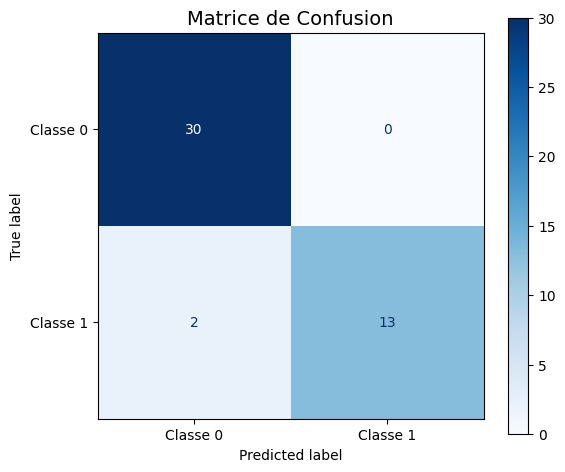

In [12]:
# Visualisation
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Classe 0', 'Classe 1'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
ax.set_title('Matrice de Confusion', fontsize=14)
plt.tight_layout()
plt.show()

---

## 3.7 Métriques de Classification

### Le rapport complet : `classification_report`

Scikit-learn fournit un rapport qui combine toutes ces métriques :

In [17]:
from sklearn.metrics import classification_report

print("📊 Rapport de Classification")
print("=" * 55)
print(classification_report(y_test_iris, y_pred_iris, target_names=['Classe 0', 'Classe 1']))

📊 Rapport de Classification
              precision    recall  f1-score   support

    Classe 0       0.94      1.00      0.97        30
    Classe 1       1.00      0.87      0.93        15

    accuracy                           0.96        45
   macro avg       0.97      0.93      0.95        45
weighted avg       0.96      0.96      0.95        45



### Comment lire ce rapport ?

| Colonne | Signification |
|---------|---------------|
| **precision** | Fiabilité des prédictions positives pour cette classe |
| **recall** | Taux de détection des vrais exemples de cette classe |
| **f1-score** | Équilibre precision/recall |
| **support** | Nombre d'exemples de cette classe dans le test set |
| **macro avg** | Moyenne simple (traite toutes les classes également) |
| **weighted avg** | Moyenne pondérée par le support |

### Precision : "Parmi mes alertes, combien sont correctes ?"

$$Precision = \frac{TP}{TP + FP}$$

- **Haute Precision** = Peu de fausses alertes
- Utile quand les fausses alertes sont coûteuses (ex: spam filter qui bloque des emails importants)

In [13]:
from sklearn.metrics import precision_score

precision = precision_score(y_test_iris, y_pred_iris)

print(f"Precision = TP / (TP + FP) = {TP} / ({TP} + {FP}) = {precision:.2%}")
print(f"\n💡 {precision:.0%} des prédictions 'Positif' sont correctes")

Precision = TP / (TP + FP) = 13 / (13 + 0) = 100.00%

💡 100% des prédictions 'Positif' sont correctes


### Recall : "Parmi les vrais cas, combien ai-je trouvés ?"

$$Recall = \frac{TP}{TP + FN}$$

- **Haut Recall** = Peu de cas manqués
- Utile quand manquer un cas est grave (ex: diagnostic de cancer)

In [14]:
from sklearn.metrics import recall_score

recall = recall_score(y_test_iris, y_pred_iris)

print(f"Recall = TP / (TP + FN) = {TP} / ({TP} + {FN}) = {recall:.2%}")
print(f"\n💡 {recall:.0%} des vrais positifs ont été détectés")

Recall = TP / (TP + FN) = 13 / (13 + 2) = 86.67%

💡 87% des vrais positifs ont été détectés


### F1-Score : L'équilibre Precision-Recall

$$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

Le F1-Score est la **moyenne harmonique** — il pénalise fortement si l'une des deux métriques est basse.

In [15]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test_iris, y_pred_iris)

print(f"F1-Score = {f1:.2%}")
print(f"\n💡 C'est un compromis entre Precision ({precision:.0%}) et Recall ({recall:.0%})")

F1-Score = 92.86%

💡 C'est un compromis entre Precision (100%) et Recall (87%)


### ROC-AUC : Évaluer à tous les seuils

La courbe **ROC** (Receiver Operating Characteristic) trace le Recall vs le Taux de Faux Positifs pour **tous les seuils de décision**.

L'**AUC** (Area Under Curve) résume cette courbe en un seul chiffre :
- AUC = 1.0 → Modèle parfait
- AUC = 0.5 → Modèle aléatoire (inutile)
- AUC > 0.8 → Bon modèle

ROC-AUC = 0.9978


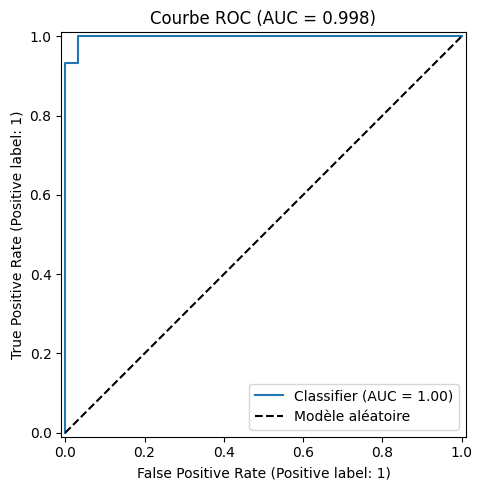

In [16]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

# Pour ROC-AUC, on a besoin des probabilités
y_proba_iris = clf.predict_proba(X_test_iris)[:, 1]

auc = roc_auc_score(y_test_iris, y_proba_iris)
print(f"ROC-AUC = {auc:.4f}")

# Visualiser la courbe ROC
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test_iris, y_proba_iris, ax=ax)
ax.plot([0, 1], [0, 1], 'k--', label='Modèle aléatoire')
ax.set_title(f'Courbe ROC (AUC = {auc:.3f})')
ax.legend()
plt.tight_layout()
plt.show()

---

## 3.8 Métriques de Régression

Pour les problèmes de régression, `.score()` retourne le R². Mais il existe d'autres métriques importantes :

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Rappel : notre modèle de régression
y_pred_reg = model.predict(X_test)

# Calculer les métriques
mae = mean_absolute_error(y_test, y_pred_reg)
mse = mean_squared_error(y_test, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_reg)

print("📊 Métriques de Régression")
print("=" * 50)
print(f"MAE  (Mean Absolute Error)  : {mae:.2f}")
print(f"RMSE (Root Mean Squared Error) : {rmse:.2f}")
print(f"R²   (Coefficient de détermination) : {r2:.4f}")

📊 Métriques de Régression
MAE  (Mean Absolute Error)  : 9.24
RMSE (Root Mean Squared Error) : 11.52
R²   (Coefficient de détermination) : 0.9850


### Comprendre ces métriques

| Métrique | Formule intuitive | Interprétation |
|----------|-------------------|----------------|
| **MAE** | Moyenne des \|erreurs\| | "En moyenne, je me trompe de X unités" |
| **RMSE** | Racine(Moyenne des erreurs²) | Pénalise plus les grosses erreurs que MAE |
| **R²** | 1 - (erreur_modèle / erreur_baseline) | "Mon modèle explique X% de la variance" |

```
┌─────────────────────────────────────────────────────────────────────┐
│              QUAND UTILISER QUELLE MÉTRIQUE ?                       │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│   MAE  → Quand toutes les erreurs comptent également               │
│          Facile à interpréter (même unité que y)                   │
│                                                                     │
│   RMSE → Quand les grosses erreurs sont plus graves                │
│          (ex: prédiction de prix, erreur de 10000€ >> 100€)        │
│                                                                     │
│   R²   → Pour comparer des modèles sur différents datasets         │
│          Valeur entre 0 et 1 (ou négative si très mauvais)         │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

***Exemples concrets pour chaque métrique de régression***

**MAE : Prédiction de température quotidienne**

```python
Valeurs réelles :    [20°C, 22°C, 18°C]
Prédictions :        [19°C, 23°C, 20°C]
Erreurs absolues :   [1°C,  1°C,  2°C]

MAE = (1 + 1 + 2)/3 = 1.33°C
```
→ **Interprétation** : En moyenne, le modèle se trompe de 1.33°C. C'est intuitif car c'est la même unité que la température.

**RMSE : Estimation de prix immobilier**

```python
Valeurs réelles :    [200 000€, 300 000€, 500 000€]
Prédictions :        [190 000€, 310 000€, 450 000€]
Erreurs :            [-10 000€, +10 000€, -50 000€]

RMSE = √[ (10000² + 10000² + 50000²)/3 ] ≈ 29 814€
```
→ **Pourquoi RMSE ici ?** Une erreur de 50 000€ est bien plus grave qu'une de 10 000€. Le RMSE pénalise fortement cette grosse erreur, contrairement au MAE qui donnerait 23 333€.

**R² : Comparaison de modèles sur différentes villes**

```python
Modèle A (Paris) : R² = 0.85
Modèle B (Lyon) :  R² = 0.72

→ Le modèle explique 85% de la variance des prix à Paris
→ Le modèle explique 72% de la variance des prix à Lyon
→ Modèle A performe mieux RELATIVEMENT à ses données
```

**Astuce visuelle :** Imaginez prédire l'heure d'arrivée d'un train :
- MAE → Moyenne des minutes de retard
- RMSE → Très sévère si un train a 3h de retard (même si les autres sont à l'heure)
- R² → Compare deux compagnies ferroviaires sur différentes lignes

---

## 3.9 Guide de sélection des métriques

```
┌─────────────────────────────────────────────────────────────────────┐
│        QUELLE MÉTRIQUE POUR QUEL CONTEXTE ?                         │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  CLASSIFICATION                                                     │
│  ──────────────                                                     │
│   Classes équilibrées          → Accuracy, F1                       │
│   Classes déséquilibrées       → F1, ROC-AUC (pas accuracy !)      │
│   Coût élevé des FN (manqués)  → RECALL (médical, sécurité)        │
│   Coût élevé des FP (alertes)  → PRECISION (spam, recommandations) │
│   Comparaison de modèles       → ROC-AUC                           │
│                                                                     │
│  RÉGRESSION                                                         │
│  ──────────                                                         │
│   Interprétabilité business    → MAE (même unité que y)            │
│   Pénaliser grosses erreurs    → RMSE                              │
│   Comparaison entre datasets   → R²                                │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

In [19]:
# Fonction utilitaire : évaluer un classificateur
def evaluer_classification(y_vrai, y_pred, y_proba=None):
    """Affiche toutes les métriques de classification."""
    from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                                 f1_score, roc_auc_score)
    
    print("📊 Métriques de Classification")
    print("=" * 40)
    print(f"Accuracy  : {accuracy_score(y_vrai, y_pred):.4f}")
    print(f"Precision : {precision_score(y_vrai, y_pred):.4f}")
    print(f"Recall    : {recall_score(y_vrai, y_pred):.4f}")
    print(f"F1-Score  : {f1_score(y_vrai, y_pred):.4f}")
    if y_proba is not None:
        print(f"ROC-AUC   : {roc_auc_score(y_vrai, y_proba):.4f}")

# Test
evaluer_classification(y_test_iris, y_pred_iris, y_proba_iris)

📊 Métriques de Classification
Accuracy  : 0.9556
Precision : 1.0000
Recall    : 0.8667
F1-Score  : 0.9286
ROC-AUC   : 0.9978


In [20]:
# Fonction utilitaire : évaluer un régresseur
def evaluer_regression(y_vrai, y_pred):
    """Affiche toutes les métriques de régression."""
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    
    mae = mean_absolute_error(y_vrai, y_pred)
    rmse = np.sqrt(mean_squared_error(y_vrai, y_pred))
    r2 = r2_score(y_vrai, y_pred)
    
    print("📊 Métriques de Régression")
    print("=" * 40)
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

# Test
evaluer_regression(y_test, y_pred)

📊 Métriques de Régression
MAE  : 9.2428
RMSE : 11.5162
R²   : 0.9850


---

## 🔑 Paramètres vs Hyperparamètres

C'est une distinction **fondamentale** en Machine Learning :

```
┌─────────────────────────────────────────────────────────────────┐
│              PARAMÈTRES vs HYPERPARAMÈTRES                      │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│   PARAMÈTRES                    HYPERPARAMÈTRES                 │
│   ══════════                    ════════════════                │
│                                                                 │
│   • Appris par le modèle        • Définis par VOUS              │
│                                  . À la création du modèle      │
│   • Pendant .fit()              • AVANT .fit()                  │
│   • Automatiques                • Manuels (ou tuning)           │
│                                                                 │
│   Exemples :                    Exemples :                      │
│   - Coefficients (LinearReg)    - n_estimators (RandomForest)   │
│   - Poids des neurones (NN)     - max_depth (DecisionTree)      │
│   - Splits des arbres           - learning_rate (GradientBoost) │
│                                 - C (LogisticRegression)        │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
```

In [21]:
# Exemple : Les hyperparamètres sont définis À LA CRÉATION du modèle
from sklearn.ensemble import RandomForestClassifier

# Ces valeurs sont des HYPERPARAMÈTRES (définis par nous)
rf = RandomForestClassifier(
    n_estimators=100,    # Nombre d'arbres
    max_depth=5,         # Profondeur maximale
    random_state=42
)

print("Hyperparamètres définis :")
print(f"  - n_estimators : {rf.n_estimators}")
print(f"  - max_depth : {rf.max_depth}")
print("\nCes valeurs ne changeront PAS pendant .fit()")

Hyperparamètres définis :
  - n_estimators : 100
  - max_depth : 5

Ces valeurs ne changeront PAS pendant .fit()


---

## 📖 Définition

```
┌─────────────────────────────────────────────────────────────────┐
│ 📖 DÉFINITION : API Scikit-Learn                                │
│                                                                 │
│ L'API (Application Programming Interface) de scikit-learn      │
│ définit une interface commune pour tous les modèles :          │
│                                                                 │
│ • .fit(X, y) — Entraîne le modèle sur les données              │
│ • .predict(X) — Génère des prédictions                         │
│ • .score(X, y) — Calcule la performance (métrique par défaut)  │
│ • .predict_proba(X) — Probabilités (classification)            │
│                                                                 │
│ Pour une évaluation complète, utilisez les fonctions de        │
│ sklearn.metrics : confusion_matrix, classification_report,     │
│ precision_score, recall_score, f1_score, roc_auc_score,        │
│ mean_absolute_error, mean_squared_error, r2_score.             │
└─────────────────────────────────────────────────────────────────┘
```

---

## 🎯 Exercice pratique : Évaluation complète

Entraînons un modèle et évaluons-le avec toutes les métriques appropriées.

In [22]:
# Charger le dataset Iris complet (3 classes cette fois)
iris_full = load_iris()
X_full = iris_full.data
y_full = iris_full.target

print(f"Dataset Iris : {X_full.shape[0]} exemples, {X_full.shape[1]} features")
print(f"Classes : {iris_full.target_names}")

Dataset Iris : 150 exemples, 4 features
Classes : ['setosa' 'versicolor' 'virginica']


In [23]:
# ÉTAPE 1 : Séparer les données (avec stratification car classification)
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full, y_full,
    test_size=0.2,
    stratify=y_full,
    random_state=42
)

print(f"Train : {len(X_train_full)} exemples")
print(f"Test : {len(X_test_full)} exemples")

Train : 120 exemples
Test : 30 exemples


In [24]:
# ÉTAPE 2 : Créer et entraîner le modèle
clf_full = DecisionTreeClassifier(max_depth=3, random_state=42)
clf_full.fit(X_train_full, y_train_full)

print("✅ Modèle entraîné !")

✅ Modèle entraîné !


In [25]:
# ÉTAPE 3 : Prédire
y_pred_full = clf_full.predict(X_test_full)

print("Premières prédictions :")
for i in range(5):
    pred_name = iris_full.target_names[y_pred_full[i]]
    true_name = iris_full.target_names[y_test_full[i]]
    match = "✓" if pred_name == true_name else "✗"
    print(f"  {match} Prédit: {pred_name:12} | Réel: {true_name}")

Premières prédictions :
  ✓ Prédit: setosa       | Réel: setosa
  ✓ Prédit: virginica    | Réel: virginica
  ✓ Prédit: versicolor   | Réel: versicolor
  ✓ Prédit: versicolor   | Réel: versicolor
  ✓ Prédit: setosa       | Réel: setosa


In [26]:
# ÉTAPE 4 : Évaluer avec .score() (accuracy)
score_train_full = clf_full.score(X_train_full, y_train_full)
score_test_full = clf_full.score(X_test_full, y_test_full)

print(f"\n📊 Performance (accuracy) :")
print(f"  - Train : {score_train_full:.2%}")
print(f"  - Test  : {score_test_full:.2%}")

# Analyse de l'overfitting
ecart = score_train_full - score_test_full
if ecart < 0.05:
    print(f"\n✅ Pas d'overfitting détecté (écart de {ecart:.2%})")
else:
    print(f"\n⚠️ Possible overfitting (écart de {ecart:.2%})")


📊 Performance (accuracy) :
  - Train : 98.33%
  - Test  : 96.67%

✅ Pas d'overfitting détecté (écart de 1.67%)


In [27]:
# ÉTAPE 5 : Évaluation complète avec classification_report
print("\n📊 Rapport de Classification Complet")
print("=" * 55)
print(classification_report(y_test_full, y_pred_full, target_names=iris_full.target_names))


📊 Rapport de Classification Complet
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



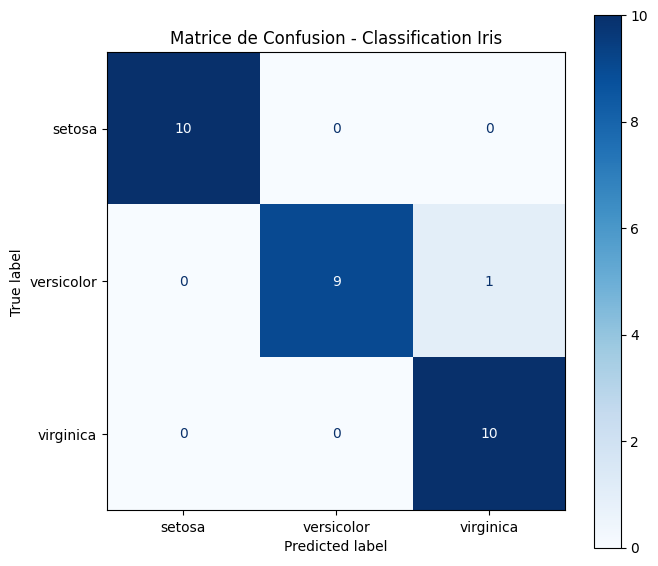

In [28]:
# ÉTAPE 6 : Matrice de confusion multiclasse
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test_full, y_pred_full,
    display_labels=iris_full.target_names,
    cmap='Blues',
    ax=ax
)
ax.set_title("Matrice de Confusion - Classification Iris")
plt.tight_layout()
plt.show()

---

## 🔄 L'interchangeabilité des modèles

Grâce à l'API uniforme, changer de modèle est trivial :

In [34]:
# Testons plusieurs modèles avec LE MÊME CODE
modeles = [
    ("Decision Tree", DecisionTreeClassifier(max_depth=3, random_state=42)),
    ("Random Forest", RandomForestClassifier(n_estimators=50, random_state=42)),
    ("Logistic Regression", LogisticRegression(max_iter=200, random_state=42)),
]

print("Comparaison des modèles :")
print("─" * 60)

for nom, modele in modeles:
    # Même pattern pour TOUS les modèles !
    modele.fit(X_train_full, y_train_full)
    y_pred_m = modele.predict(X_test_full)

    from sklearn.metrics import accuracy_score
    acc = accuracy_score(y_test_full, y_pred_m) 
    f1 = f1_score(y_test_full, y_pred_m, average='weighted')
    
    print(f"{nom:25} → Accuracy: {acc:.2%}  |  F1: {f1:.2%}")

Comparaison des modèles :
────────────────────────────────────────────────────────────
Decision Tree             → Accuracy: 96.67%  |  F1: 96.66%
Random Forest             → Accuracy: 90.00%  |  F1: 89.97%
Logistic Regression       → Accuracy: 96.67%  |  F1: 96.66%


**C'est la puissance de l'API uniforme** : le code reste identique, seul le modèle change !

---

## 🧠 Réflexion métacognitive

1. **Pouvez-vous décrire le pattern fit/predict de mémoire ?** Quelles sont les 3 méthodes principales ?

2. **Quelle est la différence entre paramètres et hyperparamètres ?** Donnez un exemple de chaque.

3. **Pourquoi `.score()` seul n'est pas suffisant ?** Donnez un exemple où l'accuracy est trompeuse.

4. **Dans quel contexte prioriseriez-vous le Recall plutôt que la Precision ?**

---

## 📝 Résumé

### API scikit-learn

| Méthode | Rôle | Utilisé pour |
|---------|------|-------------|
| `.fit(X, y)` | Entraîner | Apprendre les paramètres |
| `.predict(X)` | Prédire | Générer des prédictions |
| `.predict_proba(X)` | Probabilités | Classification uniquement |
| `.score(X, y)` | Évaluer | Métrique par défaut (R² ou accuracy) |

### Métriques de Classification

| Métrique | Question qu'elle répond | Quand l'utiliser |
|----------|------------------------|------------------|
| **Accuracy** | % de prédictions correctes | Classes équilibrées |
| **Precision** | Parmi mes alertes, combien sont vraies ? | Fausses alertes coûteuses |
| **Recall** | Parmi les vrais cas, combien trouvés ? | Cas manqués graves |
| **F1** | Équilibre Precision-Recall | Compromis |
| **ROC-AUC** | Capacité de discrimination | Comparaison de modèles |

### Métriques de Régression

| Métrique | Question qu'elle répond | Quand l'utiliser |
|----------|------------------------|------------------|
| **MAE** | Erreur moyenne absolue | Interprétabilité |
| **RMSE** | Erreur (pénalise les grosses) | Grosses erreurs graves |
| **R²** | % de variance expliquée | Comparaison entre datasets |

### Code essentiel

```python
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score,
                             mean_absolute_error, mean_squared_error, r2_score)

# Classification
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

# Régression
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
```

**Règles d'or :**
- Toujours `.fit()` AVANT `.predict()`
- Ne jamais `.fit()` sur le test set
- Comparer train score et test score pour détecter l'overfitting
- **Ne jamais se fier à une seule métrique** — regarder le contexte business !

---

## ➡️ Prochaine leçon

Dans la **Leçon 2.4 : Pipelines scikit-learn**, nous allons découvrir comment **enchaîner** preprocessing et modèle en une seule structure — propre, reproductible, et sans risque de data leakage.

**Question de transition :** Comment garantir que le preprocessing et l'entraînement utilisent toujours les mêmes données, dans le bon ordre ?